In [1]:
!pip install -U "langchain>=1.3.14"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.0/148.0 kB 1.2 MB/s eta 0:00:00
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.16
    Uninstalling langchain-1.3.16:
      Successfully uninstalled langchain-1.3.16


In [2]:
!pip install  langchain-openai langchain-community langgraph python-dotenv langchain-mcp-adapters langchain-chroma chromadb pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 735.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.1/385.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.7/224.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0

In [3]:
!pip install langchain-anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 kB 836.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.5 MB/s eta 0:00:00


In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

False

In [5]:
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')

In [6]:
from langchain.chat_models import init_chat_model

model = init_chat_model('openai:gpt-5-mini')
model.invoke('Hi')
print("Cinebot's Brain is connected")

Cinebot's Brain is connected


In [7]:

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langchain.tools import tool as tool_rt, ToolRuntime
from dataclasses import dataclass
from rich import print


In [8]:
@dataclass
class CineBotContext:
  user_name:str
  #geo_state:str # Delhi or Bangalore or Chennai

In [9]:
agent_with_context = create_agent(
    model="openai:gpt-5-mini",
    tools=[],
    context_schema=CineBotContext,   # declares the SHAPE of context this agent expects
)

In [10]:
result = agent_with_context.invoke(
    {"messages": [{"role": "user", "content": "What's my name?"}]},
    context=CineBotContext(user_name="Priya"),   # injected at invocation time
)

# Runtime Inside Tools : ToolRuntime

In [11]:
@dataclass
class CustomerContext:
  user_id:str


In [12]:
from langgraph.store.memory import InMemoryStore

loyalty_store=InMemoryStore()

In [23]:
@tool
def fetch_customer_preferences(runtime: ToolRuntime[CustomerContext])-> str:
  "Feth the customer's Saved Preferences from a long term Memory"
  user_id=runtime.context.user_id
  preferences = "No Preferences"

  if runtime.store:
    if memory := runtime.store.get(('users'),user_id):
      preferences = memory.value['preferences']

  return preferences

In [14]:
pref_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[fetch_customer_preferences],
    context_schema=CustomerContext,
    store=loyalty_store,
)

### Invoking the `pref_agent`

Now, let's invoke the `pref_agent` with a `CustomerContext` to fetch the customer's preferences. Since no preferences are stored for this `user_id` yet, it should return 'No Preferences'.

In [21]:
result = pref_agent.invoke(
    {"messages": [{"role": "user", "content": "What are my preferences?"}]},
    context=CustomerContext(user_id="user123"),
)
print(result)

{
    'messages': [
        HumanMessage(
            content='What are my preferences?',
            additional_kwargs={},
            response_metadata={},
            id='413734b4-c02e-4d94-af92-cebff9c7bdc7'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 20,
                    'prompt_tokens': 130,
                    'total_tokens': 150,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EI5PvWl8eoUyiDlAznpp4eIrQTJ2f',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a04be1-091b-73a1-b796-9f10c6346e06-0',
            tool_calls=[
                {
                    'name': 'fetch_customer_preferences',
                    'args': {},
                    'id': 'call_acIFtsI0nlrrE7sfOO3y5jhU',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 130,
                'output_tokens': 20,
                'total_tokens': 150,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='No Preferences',
            name='fetch_customer_preferences',
            id='43a15622-5ce1-4e4c-829f-08fcba5be2cc',
            tool_call_id='call_acIFtsI0nlrrE7sfOO3y5jhU'
        ),
        AIMessage(
            content='I checked your saved preferences and none are stored.\n\nWould you like to set some? Examples 
you can tell me to save:\n- Language and tone (e.g., English, concise/formal/friendly)\n- Units (metric or 
imperial)\n- Notification preferences (email, SMS, none)\n- Default location, currency, or shipping address\n- 
Dietary restrictions or accessibility needs\n- Topics you’re interested in (tech, finance, travel, health, etc.)\n-
Privacy or sharing settings\n\nTell me which preferences you want to add or change and I’ll save them. If you want 
suggestions, say what you use most and I’ll propose defaults.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 331,
                    'prompt_tokens': 158,
                    'total_tokens': 489,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 192,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EI5Pw5cZDnD0Xf2RjGmgoTzXqE0iM',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a04be1-1275-7af0-8dda-e881cf284fde-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 158,
   

### Storing and fetching preferences

Next, let's store some preferences in the `loyalty_store` and then try to fetch them using the `pref_agent`.

In [22]:
loyalty_store.put(('users'), "user123", {"preferences": "Action movies, Sci-Fi"})

result_with_pref = pref_agent.invoke(
    {"messages": [{"role": "user", "content": "What are my preferences?"}]},
    context=CustomerContext(user_id="user123"),
)
print(result_with_pref)

{
    'messages': [
        HumanMessage(
            content='What are my preferences?',
            additional_kwargs={},
            response_metadata={},
            id='55edceff-d249-4c84-8717-51cf7d3f2ebd'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 84,
                    'prompt_tokens': 130,
                    'total_tokens': 214,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EI5QBPrnrdFq7JcKjWm2yvVjtubFD',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a04be1-4c67-7811-abf8-3df8ed601e29-0',
            tool_calls=[
                {
                    'name': 'fetch_customer_preferences',
                    'args': {},
                    'id': 'call_Ll2y8heom2HkVns7DgMhpsjw',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 130,
                'output_tokens': 84,
                'total_tokens': 214,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Action movies, Sci-Fi',
            name='fetch_customer_preferences',
            id='1a34a5a5-5ed2-4aae-b924-f60b0fc95907',
            tool_call_id='call_Ll2y8heom2HkVns7DgMhpsjw'
        ),
        AIMessage(
            content='Your saved preferences are: Action movies and Sci‑Fi.\n\nWould you like to:\n- Get 
personalized recommendations now?\n- Add or remove any genres or items?\n- Save favorite actors, directors, or 
platforms?\n\nTell me which and I’ll update or show suggestions.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 190,
                    'prompt_tokens': 161,
                    'total_tokens': 351,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 128,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EI5QDXI3RIJEadugzEUn6gszenYgl',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a04be1-5373-7ce0-98c0-97dd53b44025-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 161,
                'output_tokens': 190,
                'total_tokens': 351,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 128}
            }
        )
    ]
}

# MiddleWare

In [ ]:
#NodeStyle ( Before_model, after_model)
# Wrap_style_hooks ( wrap_model_call)

# Node Style Hooks

In [24]:
from langchain.agents.middleware import before_model, after_model


In [35]:
@before_model
def log_before_model(a,b):
  pass

In [36]:
logged_agent = create_agent(model="openai:gpt-5-mini", tools=[fetch_customer_preferences], middleware=[log_before_model])


In [38]:
result = logged_agent.invoke({"messages": [("user", "Get user preferences")]}, context=CustomerContext(user_id="user123"))

# Dynamic Prompting
A dynamic prompt is a system prompt generated at runtime based on the current user/context/state, instead of being fixed for every request.

In [39]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt
from langchain.agents.middleware.types import ModelRequest


@dataclass
class CustomerContext:
    user_role: str


@dynamic_prompt
def role_based_prompt(request: ModelRequest) -> str:
    role = request.runtime.context.user_role

    if role == "admin":
        return "You are an expert assistant. Give detailed technical answers."

    return "You are a helpful assistant. Explain things simply."


agent_dynamic_prompt = create_agent(
    model="openai:gpt-5",
    tools=[],
    middleware=[role_based_prompt],
    context_schema=CustomerContext,
)
result = agent_dynamic_prompt.invoke({"messages": [("user", "Explain Data science")]}, context=CustomerContext(user_role="admin"))
print(result)

{
    'messages': [
        HumanMessage(
            content='Explain Data science',
            additional_kwargs={},
            response_metadata={},
            id='5674ab80-6774-4bba-b8de-955375050cdd'
        ),
        AIMessage(
            content='Data science is the discipline of extracting reliable, actionable value from data using 
statistics, computing, and domain knowledge, and operationalizing that value in products or decisions. It spans the
full lifecycle from problem framing to production deployment and monitoring.\n\nCore problem types\n- Descriptive 
and diagnostic: What happened and why? EDA, dashboards, anomaly detection.\n- Predictive: What will happen? 
Regression, classification, time-series forecasting.\n- Prescriptive: What should we do? Optimization, decision 
analysis, reinforcement learning, causal uplift.\n- Causal inference and experimentation: Estimating treatment 
effects via randomized experiments or observational methods.\n- Unsupervised learning: Structure discovery 
(clustering, dimensionality reduction, density estimation, topic modeling), recommendation.\n\nData modalities\n- 
Structured/tabular, time series, logs/streams.\n- Text (NLP), images/video (CV), audio, graphs.\n- Static vs 
temporal, labeled vs unlabeled, batch vs streaming.\n\nTypical lifecycle\n1) Problem framing and metric design\n- 
Translate a business question to a clear target variable, constraints, and success metrics linked to value (e.g., 
revenue lift, reduced risk).\n- Choose offline metrics aligned to production objectives (e.g., for imbalanced 
classification prefer PR-AUC, cost-sensitive metrics).\n- Define the decision surface (thresholds, risk/return 
tradeoffs), acceptance criteria, and guardrail metrics.\n\n2) Data acquisition and governance\n- Source data from 
warehouses (SQL), data lakes (object storage), event streams (Kafka/Kinesis), external APIs.\n- Understand data 
lineage, refresh cadence, completeness, and schema evolution.\n- Handle PII/PHI via minimization, access controls, 
encryption, and compliance (GDPR/CCPA/HIPAA).\n- Establish data contracts and quality SLAs.\n\n3) Data preparation 
and feature engineering\n- Cleaning: deduplication, outlier handling, type coercion, missingness analysis 
(MCAR/MAR/MNAR). Impute (mean/median/knn/mice), add missingness indicators when informative.\n- Leakage control: 
ensure features available at prediction time (especially with temporal data); fit scalers/encoders only on training
folds.\n- Splitting: proper holdout and cross-validation. For time series use time-based CV (rolling origin). For 
i.i.d. data use stratified k-fold for class imbalance.\n- Encoding/scaling: one-hot, target encoding with 
leakage-safe schemes, standard/robust/min-max scaling; log transforms for skew.\n- Class imbalance: class weights, 
focal loss, calibrated thresholds, specialized metrics; cautious use of resampling (SMOTE).\n- Modality-specific:\n
- Text: tokenization, TF-IDF, subword embeddings, pretrained LLM embeddings, domain adaptation.\n  - Images: 
resizing, normalization, augmentations; transfer learning.\n  - Time series: lag/lead features, rolling stats, 
seasonality decomposition, holiday/price/exogenous covariates.\n  - Graphs: node2vec, GNN features (if 
applicable).\n\n4) Exploratory data analysis (EDA)\n- Distribution shapes, heavy tails, multimodality; 
feature-target relationships; correlation/collinearity.\n- Stability across time/slices; segment performance; data 
drift/pre-drift indicators.\n- Hypothesis formulation and sanity checks (e.g., label prevalence, latency, 
missingness over time).\n\n5) Modeling\n- Baselines: naive predictors, linear/logistic regression; set 
benchmarks.\n- Traditional ML for tabular data: regularized GLMs (L1/L2/elastic net), tree ensembles (Random 
Forest, Gradient Boosting like XGBoost/LightGBM/CatBoost), kNN, SVM.\n- Deep learning for high-dimensional 
modalities: CNNs/ViTs for vision, RNN/Transformers for sequences and NLP, m

# Human in the Loop ( In Depth )

In [8]:

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
model = init_chat_model("openai:gpt-5-mini")

In [9]:
from rich import print

In [10]:
@tool
def cancel_booking(booking_id: str,runtime:ToolRuntime) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."

In [11]:
# An Agent without HITL
unguarded_agent = create_agent(model="openai:gpt-5-mini", tools=[cancel_booking])
result = unguarded_agent.invoke({"messages": [("user", "Cancel my booking BK1042")]})
print(result)

{
    'messages': [
        HumanMessage(
            content='Cancel my booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='ba829d72-1ad3-443d-a2ea-32eb18006527'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 90,
                    'prompt_tokens': 134,
                    'total_tokens': 224,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EIF6MZg5ursaOTtsyesJaKaAnKFFh',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a04e19-1454-7803-a77e-229700d6451a-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'BK1042'},
                    'id': 'call_Knc3YblNDSZ9jC3EG6PHEhZa',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 134,
                'output_tokens': 90,
                'total_tokens': 224,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Booking BK1042 cancelled.',
            name='cancel_booking',
            id='5df6523a-583e-41ba-b878-9d4a3fae528f',
            tool_call_id='call_Knc3YblNDSZ9jC3EG6PHEhZa'
        ),
        AIMessage(
            content='Done — your booking BK1042 has been cancelled successfully. This cancellation is 
irreversible.\n\nWould you like a cancellation receipt, help checking refund status, or assistance rebooking?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 235,
                    'prompt_tokens': 171,
                    'total_tokens': 406,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 192,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EIF6PxX4owYwNpOfiblt4rR0eyO8j',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a04e19-2076-7b20-b690-bfffc9d93efc-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 171,
                'output_tokens': 235,
                'total_tokens': 406,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 192}
            }
        )
    ]
}

In [65]:
result = unguarded_agent.invoke({"messages": [("user", "Hi I am Mayank")]})

In [66]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Hi I am Mayank',
            additional_kwargs={},
            response_metadata={},
            id='f55fc516-47ad-4751-8f7c-78a72811ec2c'
        ),
        AIMessage(
            content='Hi Mayank — nice to meet you! How can I help you today?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 25,
                    'prompt_tokens': 133,
                    'total_tokens': 158,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EIAIV0tB6ZF9f6UUrCnQ235vCqzQY',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a04cff-4e53-7330-9fee-fb80a234d6db-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 133,
                'output_tokens': 25,
                'total_tokens': 158,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

In [67]:
result = unguarded_agent.invoke({"messages": [("user", "Who am I?")]})

In [47]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Who am I?',
            additional_kwargs={},
            response_metadata={},
            id='d7d90897-4c74-4cca-8841-c71d0317a387'
        ),
        AIMessage(
            content='I don’t know — I don’t have access to your personal data or past messages unless you tell me. 
Do you mean one of these?\n\n- Your account/username on a site (technical identification)\n- Who you are as a 
person (identity, values, roles)\n- A philosophical or existential question\n- A riddle or “guess who” game\n\nIf 
you want help exploring who you are as a person, pick one and I can do that. Here are two quick options you can 
choose now:\n\n1) Short self-discovery summary (fast): Answer these five quick questions and I’ll write a short 
“Who you are” paragraph.\n   - Three things you enjoy\n   - Two skills you’re good at\n   - One value that matters 
to you\n   - How friends/family describe you in a few words\n   - One recent moment you felt proud of\n\n2) Guided 
reflection exercise (3–5 minutes): I’ll give prompts to journal on and then summarize themes and possible next 
steps (career, relationships, personal growth).\n\nWhich do you want, or did you mean something else?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 554,
                    'prompt_tokens': 132,
                    'total_tokens': 686,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 320,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EI9zYVT2Yr3HznYaXepmd5b268RP5',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a04ced-5c45-7e92-9835-8425765c26f6-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 132,
                'output_tokens': 554,
                'total_tokens': 686,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 320}
            }
        )
    ]
}

In [68]:
result.interrupts

AttributeError: 'dict' object has no attribute 'interrupts'

In [12]:
@tool
def send_booking_confirmation(booking_id: str, email: str) -> str:
    """Send a booking confirmation email. Safe, no approval needed."""
    return f"Confirmation for {booking_id} sent to {email}."


In [13]:
guarded_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[cancel_booking, send_booking_confirmation],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "cancel_booking": True,               # all four decisions allowed (default config)
                "send_booking_confirmation": False,    # safe operation, auto-approved, never pauses
            },
            description_prefix="CineBot action pending your approval",
        ),
    ],
    checkpointer=InMemorySaver(),   # REQUIRED -- HITL needs to pause and later resume
)

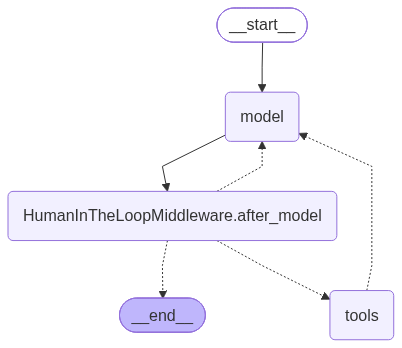

In [75]:
guarded_agent

In [76]:
config = {"configurable": {"thread_id": "hitl-demo-1122"}}

In [77]:
result = guarded_agent.invoke(
    {"messages": [("user", "Cancel booking BK1042")]},
    config=config,
    version="v2",   # the current, recommended invoke pattern for reading interrupts
)

In [78]:
print(result)

GraphOutput(
    value={
        'messages': [
            HumanMessage(
                content='Cancel booking BK1042',
                additional_kwargs={},
                response_metadata={},
                id='02191e87-d284-465b-8f54-f024a200323a'
            ),
            AIMessage(
                content='I can do that — canceling booking BK1042 is irreversible. Do you want me to proceed with 
the cancellation?\n\nAlso, would you like a cancellation confirmation email sent? If so, please provide the email 
address to send it to.',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 313,
                        'prompt_tokens': 165,
                        'total_tokens': 478,
                        'completion_tokens_details': {
                            'accepted_prediction_tokens': 0,
                            'audio_tokens': 0,
                            'reasoning_tokens': 256,
                            'rejected_prediction_tokens': 0
                        },
                        'prompt_tokens_details': {
                            'audio_tokens': 0,
                            'cache_write_tokens': None,
                            'cached_tokens': 0
                        }
                    },
                    'model_provider': 'openai',
                    'model_name': 'gpt-5-mini-2025-08-07',
                    'system_fingerprint': None,
                    'id': 'chatcmpl-EIAJBK42OITty0dAYXQ1F8RmvCyou',
                    'service_tier': 'default',
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='lc_run--01a04cff-f3d0-7f83-a304-495bca3c0952-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 165,
                    'output_tokens': 313,
                    'total_tokens': 478,
                    'input_token_details': {'audio': 0, 'cache_read': 0},
                    'output_token_details': {'audio': 0, 'reasoning': 256}
                }
            ),
            HumanMessage(
                content='Cancel booking BK1042',
                additional_kwargs={},
                response_metadata={},
                id='619aa3d4-7b2b-4353-88f1-de77accf5497'
            ),
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 218,
                        'prompt_tokens': 228,
                        'total_tokens': 446,
                        'completion_tokens_details': {
                            'accepted_prediction_tokens': 0,
                            'audio_tokens': 0,
                            'reasoning_tokens': 192,
                            'rejected_prediction_tokens': 0
                        },
                        'prompt_tokens_details': {
                            'audio_tokens': 0,
                            'cache_write_tokens': None,
                            'cached_tokens': 0
                        }
                    },
                    'model_provider': 'openai',
                    'model_name': 'gpt-5-mini-2025-08-07',
                    'system_fingerprint': None,
                    'id': 'chatcmpl-EIAKesqA78CxGQ9kC3WxCLOfDlA7I',
                    'service_tier': 'default',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--01a04d01-5381-70a2-af20-673ea5bbd516-0',
                tool_calls=[
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'id': 'call_ZR05GyS17wo8BEvqRJcKJPvU',
                   

In [79]:
result.interrupts

(Interrupt(value={'action_requests': [{'name': 'cancel_booking', 'args': {'booking_id': 'BK1042'}, 'description': "CineBot action pending your approval\n\nTool: cancel_booking\nArgs: {'booking_id': 'BK1042'}"}], 'review_configs': [{'action_name': 'cancel_booking', 'allowed_decisions': ['approve', 'edit', 'reject', 'respond']}]}, id='acf3f64db3d0e4669873f87301b226dc'),)

# Command
What we sent as an answer to Interrupt

In [80]:
resumed = guarded_agent.invoke(
    Command(
        resume={"decisions": [{"type": "approve"}]}  # or "reject"
    ),
    config=config, # Same thread ID to resume the paused conversation
    version="v2",
)

In [81]:
print(resumed)

GraphOutput(
    value={
        'messages': [
            HumanMessage(
                content='Cancel booking BK1042',
                additional_kwargs={},
                response_metadata={},
                id='02191e87-d284-465b-8f54-f024a200323a'
            ),
            AIMessage(
                content='I can do that — canceling booking BK1042 is irreversible. Do you want me to proceed with 
the cancellation?\n\nAlso, would you like a cancellation confirmation email sent? If so, please provide the email 
address to send it to.',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 313,
                        'prompt_tokens': 165,
                        'total_tokens': 478,
                        'completion_tokens_details': {
                            'accepted_prediction_tokens': 0,
                            'audio_tokens': 0,
                            'reasoning_tokens': 256,
                            'rejected_prediction_tokens': 0
                        },
                        'prompt_tokens_details': {
                            'audio_tokens': 0,
                            'cache_write_tokens': None,
                            'cached_tokens': 0
                        }
                    },
                    'model_provider': 'openai',
                    'model_name': 'gpt-5-mini-2025-08-07',
                    'system_fingerprint': None,
                    'id': 'chatcmpl-EIAJBK42OITty0dAYXQ1F8RmvCyou',
                    'service_tier': 'default',
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='lc_run--01a04cff-f3d0-7f83-a304-495bca3c0952-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 165,
                    'output_tokens': 313,
                    'total_tokens': 478,
                    'input_token_details': {'audio': 0, 'cache_read': 0},
                    'output_token_details': {'audio': 0, 'reasoning': 256}
                }
            ),
            HumanMessage(
                content='Cancel booking BK1042',
                additional_kwargs={},
                response_metadata={},
                id='619aa3d4-7b2b-4353-88f1-de77accf5497'
            ),
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 218,
                        'prompt_tokens': 228,
                        'total_tokens': 446,
                        'completion_tokens_details': {
                            'accepted_prediction_tokens': 0,
                            'audio_tokens': 0,
                            'reasoning_tokens': 192,
                            'rejected_prediction_tokens': 0
                        },
                        'prompt_tokens_details': {
                            'audio_tokens': 0,
                            'cache_write_tokens': None,
                            'cached_tokens': 0
                        }
                    },
                    'model_provider': 'openai',
                    'model_name': 'gpt-5-mini-2025-08-07',
                    'system_fingerprint': None,
                    'id': 'chatcmpl-EIAKesqA78CxGQ9kC3WxCLOfDlA7I',
                    'service_tier': 'default',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--01a04d01-5381-70a2-af20-673ea5bbd516-0',
                tool_calls=[
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'id': 'call_ZR05GyS17wo8BEvqRJcKJPvU',
                   

# Edit

In [ ]:
resumed_edit = guarded_agent.invoke(
    Command(resume={"decisions": [{
        "type": "edit",
        "edited_action": {"name": "cancel_booking", "args": {"booking_id": "BK1042"}},
    }]}),
    config=config2, version="v2",
)

In [82]:
config3 = {"configurable": {"thread_id": "hitl-demo-3"}}
guarded_agent.invoke({"messages": [("user", "Cancel booking BK1042")]}, config=config3, version="v2")

resumed_reject = guarded_agent.invoke(
    Command(resume={"decisions": [{
        "type": "reject",
        "message": "Cancellations require manager sign-off first. Ask the customer to call support.",
    }]}),
    config=config3, version="v2",
)

In [83]:
print(resumed_reject.value["messages"][-1].content)


I can’t cancel BK1042 directly — cancellations require manager sign‑off. Please call our support team to complete 
the cancellation and have the manager approve it. When you call, have this info ready: booking ID BK1042, the name 
on the booking, and the reason for cancellation.

I can help in one of these ways — tell me which you want:
- Draft a short email or support message you can send (I’ll include booking details and requested outcome).
- Write a phone script you can use when you call support.
- Prepare a brief manager escalation note you can forward (if you prefer to ask the manager in writing).

Which would you like me to prepare? If you pick email/phone script or escalation, please confirm the name on the 
booking and the reason for cancellation.

In [84]:
@tool
def ask_customer(question: str) -> str:
    """Ask the customer a clarifying question and wait for their reply."""
    return "placeholder -- never actually reached, respond intercepts this"


In [85]:

ask_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[ask_customer],
    middleware=[HumanInTheLoopMiddleware(interrupt_on={"ask_customer": {"allowed_decisions": ["respond"]}})],
    checkpointer=InMemorySaver(),
)

In [89]:
config_ask = {"configurable": {"thread_id": "hitl-demo-4"}}
ask_agent.invoke({"messages": [("user", "Cancel booking BK1042")]}, config=config_ask)

{'messages': [HumanMessage(content='Cancel booking BK1042', additional_kwargs={}, response_metadata={}, id='48fc6853-0325-4b0f-9e9e-fe945880b2be'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 203, 'prompt_tokens': 136, 'total_tokens': 339, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EIAZnltBXnUBxLxRoVGFEF0a7Kao0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a04d0f-a878-7080-b4cb-1d64a7e97df8-0', tool_calls=[{'name': 'ask_customer', 'args': {'question': 'Do you want me to cancel booking BK1042 now? Please confirm and provide the email or phone used for the booking (or the

In [90]:
resumed_agent_respond = ask_agent.invoke(
    Command(resume={"decisions": [{
        "type": "respond",
        "message": "Its Booking BK1042, for the movie interstellar",
    }]}),
    config=config_ask
)

In [88]:
print(resumed_agent_respond)

{
    'messages': [
        HumanMessage(
            content='Cancel booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='e1b5c05b-7fbd-41a0-8991-62a91674fe58'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 211,
                    'prompt_tokens': 136,
                    'total_tokens': 347,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 128,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EIAWwYjxx2lyGR2jjSVcwFH7Dh10X',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a04d0c-f740-7461-af4f-d1eee65012d9-0',
            tool_calls=[
                {
                    'name': 'ask_customer',
                    'args': {
                        'question': 'Do you want me to cancel booking BK1042 now? Please confirm and provide any 
required details: the name on the booking (or last 4 digits of phone/email), and whether you want a refund or 
credit (if applicable). Also tell me if there are any add-ons to keep or cancel.'
                    },
                    'id': 'call_cezJEMswiyUmTQuEeWEWejRL',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 136,
                'output_tokens': 211,
                'total_tokens': 347,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 128}
            }
        ),
        ToolMessage(
            content='Its Booking BK1042, for the movie interstellar',
            name='ask_customer',
            id='6ba94515-a7e9-4d3a-83d8-7b152360b5c0',
            tool_call_id='call_cezJEMswiyUmTQuEeWEWejRL'
        ),
        AIMessage(
            content='I can cancel booking BK1042 for Interstellar. Before I proceed I need two quick things:\n\n1) 
Please confirm you want me to cancel now.  \n2) For verification, provide the name on the booking or the last 4 
digits of the phone or email on the reservation.\n\nAlso tell me:\n- Do you want a refund to the original payment 
method or a credit/voucher?  \n- Any add-ons (snacks, premium seats, extras) you want to keep or cancel?\n\nIf you 
prefer, reply just “Cancel now” plus the verification info and I’ll process it.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 385,
                    'prompt_tokens': 235,
                    'total_tokens': 620,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 256,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EIAXOk9CXCTCfg551gkjB761O86Ak',
                'service_tier': 'default',
                'finish_reason': 'stop',

# Conditional Interrupts

In [91]:
from langchain.agents.middleware import ToolCallRequest

@tool
def cancel_booking_priced(booking_id: str, amount: float) -> str:
    """Cancel a booking with a refund amount."""
    return f"Booking {booking_id} cancelled, ${amount:.2f} refunded."

In [92]:
ToolCallRequest
'''
    tool_call: ToolCall
    tool: BaseTool | None
    state: Any
    runtime: ToolRuntime
'''

'\n    tool_call: ToolCall\n    tool: BaseTool | None\n    state: Any\n    runtime: ToolRuntime\n'

In [109]:
def is_large_refund(request: ToolCallRequest)-> bool:
  amount = request.tool_call['args'].get('amount',0)
  return amount >100
  # return True

In [110]:
conditional_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[cancel_booking_priced],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "cancel_booking_priced": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                    "when": is_large_refund,
                },
            },
        ),
    ],
    checkpointer=InMemorySaver(),
)


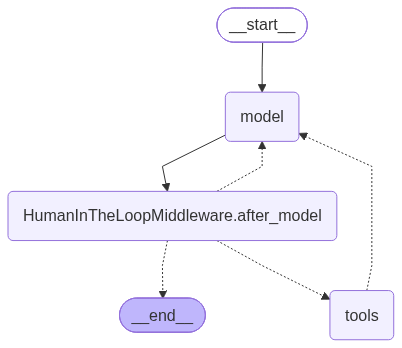

In [111]:
conditional_agent

In [112]:
config_small = {"configurable": {"thread_id": "small-refund"}}
r_small = conditional_agent.invoke(
    {"messages": [("user", "Cancel booking BK1001, refund $25")]}, config=config_small
)
print("Small refund, paused?", bool(r_small.get('__interrupt__')))

Small refund, paused? False

In [113]:
print(r_small)

{
    'messages': [
        HumanMessage(
            content='Cancel booking BK1001, refund $25',
            additional_kwargs={},
            response_metadata={},
            id='144c2739-01cb-4f29-9068-450b5e283110'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 160,
                    'prompt_tokens': 142,
                    'total_tokens': 302,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 128,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EIB2m4lrk5GBsl3QRLT7JHsUzAZ10',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a04d2b-1646-78d0-9d48-85bae4bd38f3-0',
            tool_calls=[
                {
                    'name': 'cancel_booking_priced',
                    'args': {'booking_id': 'BK1001', 'amount': 25},
                    'id': 'call_VKjKodw52yv5BOLg8CytwAjB',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 142,
                'output_tokens': 160,
                'total_tokens': 302,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 128}
            }
        ),
        ToolMessage(
            content='Booking BK1001 cancelled, $25.00 refunded.',
            name='cancel_booking_priced',
            id='f9a3dd5a-a468-44a2-b8f2-0a5ec62f43da',
            tool_call_id='call_VKjKodw52yv5BOLg8CytwAjB'
        ),
        AIMessage(
            content='Done — booking BK1001 has been cancelled and a $25.00 refund issued.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 21,
                    'prompt_tokens': 193,
                    'total_tokens': 214,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EIB2oCX6A9mNLx3S6MCMvuAAFH7s6',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a04d2b-1ddb-7873-813c-1bb36fcbfa2a-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 193,
                'output_tokens': 21,
                'total_tokens': 214,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

In [114]:
config_large = {"configurable": {"thread_id": "large-refund"}}
r_large = conditional_agent.invoke(
    {"messages": [("user", "Cancel booking BK1002, refund $500")]}, config=config_large, version="v2",
)
print("Large refund, paused?", bool(r_large.interrupts))

Large refund, paused? True

In [115]:
print(r_large)

GraphOutput(
    value={
        'messages': [
            HumanMessage(
                content='Cancel booking BK1002, refund $500',
                additional_kwargs={},
                response_metadata={},
                id='aaa2c3ec-0c24-450e-8d9c-45a126ea2298'
            ),
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 160,
                        'prompt_tokens': 142,
                        'total_tokens': 302,
                        'completion_tokens_details': {
                            'accepted_prediction_tokens': 0,
                            'audio_tokens': 0,
                            'reasoning_tokens': 128,
                            'rejected_prediction_tokens': 0
                        },
                        'prompt_tokens_details': {
                            'audio_tokens': 0,
                            'cache_write_tokens': None,
                            'cached_tokens': 0
                        }
                    },
                    'model_provider': 'openai',
                    'model_name': 'gpt-5-mini-2025-08-07',
                    'system_fingerprint': None,
                    'id': 'chatcmpl-EIB3FdFCyhXzG2dy6euqhzFx2FWNr',
                    'service_tier': 'default',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--01a04d2b-86e2-77b1-9d13-a018b755d099-0',
                tool_calls=[
                    {
                        'name': 'cancel_booking_priced',
                        'args': {'booking_id': 'BK1002', 'amount': 500},
                        'id': 'call_HuEJzWDDxXjBUyOlKUGLfgHZ',
                        'type': 'tool_call'
                    }
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 142,
                    'output_tokens': 160,
                    'total_tokens': 302,
                    'input_token_details': {'audio': 0, 'cache_read': 0},
                    'output_token_details': {'audio': 0, 'reasoning': 128}
                }
            )
        ]
    },
    interrupts=(
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'cancel_booking_priced',
                        'args': {'booking_id': 'BK1002', 'amount': 500},
                        'description': "Tool execution requires approval\n\nTool: cancel_booking_priced\nArgs: 
{'booking_id': 'BK1002', 'amount': 500}"
                    }
                ],
                'review_configs': [
                    {'action_name': 'cancel_booking_priced', 'allowed_decisions': ['approve', 'edit', 'reject']}
                ]
            },
            id='4e99ff8b78f359aea8a297d9e9c1eb6c'
        ),
    )
)

In [14]:
def run_interactive_hitl(agent, config):
    """A real, interactive HITL loop -- uses the CORRECTED edited_action format."""
    result = agent.invoke({"messages": [("user", "Cancel booking BK1042")]}, config=config, version="v2")
    if not result.interrupts:
        print("Nothing paused for review.")
        return

    print("CineBot wants to cancel booking BK1042. Choose a decision:")
    print("  1) approve")
    print("  2) edit     -- cancel a DIFFERENT booking ID instead")
    print("  3) reject")
    choice = input("Type 1, 2, or 3: ").strip()

    if choice == "1":
        decision = {"type": "approve"}
    elif choice == "2":
        new_id = input("Booking ID to cancel instead: ").strip()
        decision = {"type": "edit", "edited_action": {"name": "cancel_booking", "args": {"booking_id": new_id}}}
    elif choice == "3":
        reason = input("Reason: ").strip()
        decision = {"type": "reject", "message": reason}
    else:
        print("Not a valid choice.")
        return

    resumed = agent.invoke(Command(resume={"decisions": [decision]}), config=config, version="v2")
    print()
    print("Final:", resumed.value["messages"][-1].content)

run_interactive_hitl(guarded_agent, {"configurable": {"thread_id": "live-interactive-demo3"}})


CineBot wants to cancel booking BK1042. Choose a decision:

1) approve

2) edit     -- cancel a DIFFERENT booking ID instead

3) reject

Type 1, 2, or 3: 1


Final: Done — booking BK1042 has been cancelled. This action is irreversible.

Would you like a cancellation confirmation sent by email? If so, tell me the email address to send it to. I can 
also help check refund status, reschedule, or book a replacement if you’d like.